In [34]:
import torch
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [35]:
df = pd.read_csv("email.csv")

In [36]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 3 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   subject_formality_score    1000 non-null   float64
 1   sender_relationship_score  1000 non-null   float64
 2   email_type                 1000 non-null   int64  
dtypes: float64(2), int64(1)
memory usage: 23.6 KB


In [37]:
df.head()

,subject_formality_score,sender_relationship_score,email_type
0,-1.496790,0.779258,0
1,-1.217610,0.889601,0
2,-0.375945,-0.823324,1
3,0.639609,-0.362827,1
4,-1.342836,-1.040502,1


<Axes: xlabel='subject_formality_score', ylabel='sender_relationship_score'>

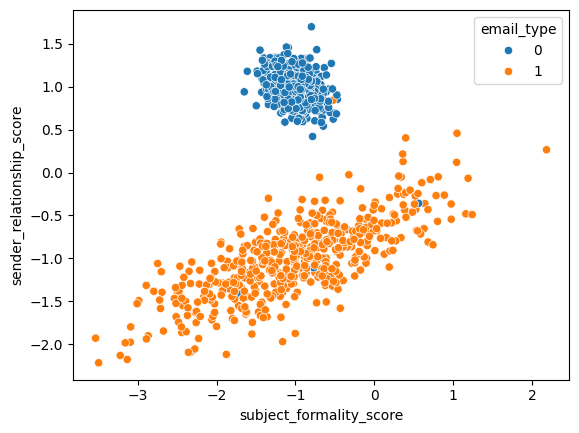

In [38]:
sns.scatterplot(x = df['subject_formality_score'], y = df['sender_relationship_score'], hue = df['email_type'])

In [39]:
X = df[['subject_formality_score', 'sender_relationship_score']].values
y = df['email_type'].values

In [40]:
from sklearn.model_selection import train_test_split

In [41]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [42]:
X_train = torch.tensor(X_train, dtype=torch.float32)
X_test = torch.tensor(X_test, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
y_test = torch.tensor(y_test, dtype=torch.float32).unsqueeze(1)

In [43]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

torch.Size([800, 2]) torch.Size([800, 1])
torch.Size([200, 2]) torch.Size([200, 1])


In [44]:
from torch import nn

In [45]:
class ClassificationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # 2 katmanlı bir model
        self.layer_1 = nn.Linear(in_features=2, out_features=5)  # 2 input
        self.layer_2 = nn.Linear(in_features=5, out_features=1)  # 1 output

    def forward(self, x):
        return self.layer_2(self.layer_1(x))

In [46]:
model_0 = ClassificationModel()

In [47]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [48]:
def calculate_accuracy(y_test, y_pred):  # torchmetrics gibi bir fonksiyon
    correct = torch.eq(y_test, y_pred).sum().item() # True/False -- (y_test == y_pred) 
    accuracy = (correct / len(y_pred)) * 100
    return accuracy

In [49]:
model_0(X_test[:5])

tensor([[-0.1342],
        [-0.2908],
        [-0.1631],
        [-0.2298],
        [-0.1364]], grad_fn=<AddmmBackward0>)

In [50]:
torch.manual_seed(42)
epochs = 200

In [51]:
for epoch in range(epochs):
    
    model_0.train()

    y_logits = model_0(X_train)
    y_pred = torch.round(torch.sigmoid(y_logits))

    loss = loss_fn(y_logits, y_train)
    acc = calculate_accuracy(y_train, y_pred)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()

    with torch.inference_mode():
        test_logits = model_0(X_test)
        test_pred = torch.round(torch.sigmoid(test_logits))

        test_loss = loss_fn(test_logits, y_test)
        test_acc = calculate_accuracy(y_test, test_pred)

        if epoch % 10 == 0:
            print(f"Epoch: {epoch} | Loss: {loss:.4f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.4f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.7235 | Accuracy: 49.75% | Test Loss: 0.7177 | Test Accuracy: 52.00%
Epoch: 10 | Loss: 0.6912 | Accuracy: 49.75% | Test Loss: 0.6844 | Test Accuracy: 52.00%
Epoch: 20 | Loss: 0.6613 | Accuracy: 49.75% | Test Loss: 0.6536 | Test Accuracy: 52.00%
Epoch: 30 | Loss: 0.6334 | Accuracy: 50.12% | Test Loss: 0.6249 | Test Accuracy: 52.00%
Epoch: 40 | Loss: 0.6070 | Accuracy: 58.63% | Test Loss: 0.5978 | Test Accuracy: 63.50%
Epoch: 50 | Loss: 0.5820 | Accuracy: 70.62% | Test Loss: 0.5721 | Test Accuracy: 76.50%
Epoch: 60 | Loss: 0.5580 | Accuracy: 82.50% | Test Loss: 0.5475 | Test Accuracy: 85.50%
Epoch: 70 | Loss: 0.5350 | Accuracy: 89.00% | Test Loss: 0.5239 | Test Accuracy: 90.00%
Epoch: 80 | Loss: 0.5128 | Accuracy: 92.62% | Test Loss: 0.5012 | Test Accuracy: 92.50%
Epoch: 90 | Loss: 0.4914 | Accuracy: 94.12% | Test Loss: 0.4793 | Test Accuracy: 94.00%
Epoch: 100 | Loss: 0.4707 | Accuracy: 95.50% | Test Loss: 0.4583 | Test Accuracy: 94.50%
Epoch: 110 | Loss: 0.4507 | Accu

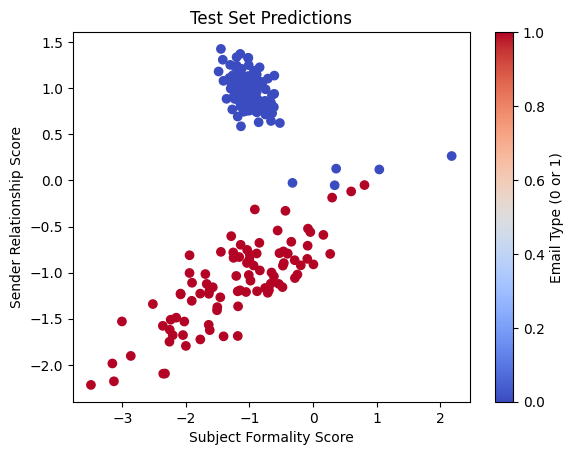

In [53]:
plt.scatter(x = X_test[:, 0].numpy(), y = X_test[:, 1].numpy(), c = test_pred.squeeze().numpy(), cmap='coolwarm')
plt.xlabel('Subject Formality Score')
plt.ylabel('Sender Relationship Score')
plt.title('Test Set Predictions')   
plt.colorbar(label='Email Type (0 or 1)')
plt.show()